# Square Attack (black-box)
Square Attack è un attacco adversarial black-box score-based.


## 1. Setup e Import


In [2]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT = Path('..')
BATCH_SIZE = 32
IMG_SIZE = 224
N_CLASSES = 5


model = models.resnet18(pretrained=True)
model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)
model = model.to(device)

model_path = ROOT / "models" / "best_resnet18.pt"
model.load_state_dict(torch.load(model_path))
model.eval()


NORMALIZE = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

TRANSFORMS = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

dataset_path = ROOT / "data" / "fruits-classification-stratified"

train_dataset = ImageFolder(root=dataset_path / 'train', transform=TRANSFORMS)
val_dataset   = ImageFolder(root=dataset_path / 'valid', transform=TRANSFORMS)
test_dataset  = ImageFolder(root=dataset_path / 'test',  transform=TRANSFORMS)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

class_names = test_dataset.classes

results_path = ROOT / "results"
results_path.mkdir(exist_ok=True)

print(f"\nSetup e import completati")


Setup e import completati


/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 2. Implementazione Square Attack (da zero)

Funzionamento:

1. crea una prima perturbazione casuale con valori -epsilon oppure +epsilon
2. seleziona casualmente una regione quadrata dell’immagine
3. modifica la perturbazione all’interno del quadrato
4. mantiene la modifica solamente se riduce il punteggio della classe corretta rispetto alle altre classi
5. ripete il procedimento fino al raggiungimento del numero massimo di query oppure fino a quando il modello sbaglia classificazione

La dimensione del quadrato diminuisce durante l’attacco: inizialmente vengono modificate regioni grandi, successivamente regioni più piccole

In [3]:
loss_fn_square = nn.CrossEntropyLoss(reduction='none')

def p_selection(p_init, query, max_queries):
    """
    Riduce progressivamente la dimensione del quadrato
    """
    query_percentage = int(query / max_queries * 10000)

    if 10 < query_percentage <= 50:
        p = p_init / 2
    elif 50 < query_percentage <= 200:
        p = p_init / 4
    elif 200 < query_percentage <= 500:
        p = p_init / 8
    elif 500 < query_percentage <= 1000:
        p = p_init / 16
    elif 1000 < query_percentage <= 2000:
        p = p_init / 32
    elif 2000 < query_percentage <= 4000:
        p = p_init / 64
    elif 4000 < query_percentage <= 6000:
        p = p_init / 128
    elif 6000 < query_percentage <= 8000:
        p = p_init / 256
    elif 8000 < query_percentage <= 10000:
        p = p_init / 512
    else:
        p = p_init

    return p


def square_attack(model, images, labels, epsilon, max_queries, p_init=0.05):
    """
    Esegue Square Attack L-infinity su un batch di immagini
    """
    images = images.clone().detach()

    batch_size, channels, height, width = images.shape

    adv_images = images.clone()
    queries = torch.zeros(batch_size, dtype=torch.long, device=images.device)

    with torch.no_grad():

        # predizioni sulle immagini originali
        clean_outputs = model(NORMALIZE(images))
        clean_preds = torch.argmax(clean_outputs, dim=1)

        # vengono attaccate solo le immagini inizialmente corrette
        correct_mask = (clean_preds == labels)

        if correct_mask.sum().item() == 0:
            perturbation = adv_images - images
            return adv_images, perturbation, queries

        correct_indices = torch.where(correct_mask)[0]

        # perturbazione iniziale con colonne verticali multiple di epsilon
        initial_perturbation = torch.empty(len(correct_indices), channels, 1, width, device=images.device)

        initial_perturbation.uniform_(-1, 1)
        initial_perturbation = initial_perturbation.sign() * epsilon

        adv_images[correct_indices] = torch.clamp(images[correct_indices] + initial_perturbation,0, 1)

        # prima query dell'attacco
        initial_outputs = model(NORMALIZE(adv_images[correct_indices]))

        best_loss = torch.full((batch_size,), -float('inf'), device=images.device)

        best_preds = clean_preds.clone()

        best_loss[correct_indices] = loss_fn_square(initial_outputs, labels[correct_indices])

        best_preds[correct_indices] = torch.argmax(initial_outputs, dim=1)

        queries[correct_indices] = 1

        # query successive
        for query in range(1, max_queries):

            active_mask = (correct_mask & (best_preds == labels) & (queries < max_queries))

            if active_mask.sum().item() == 0:
                break

            active_indices = torch.where(active_mask)[0]

            candidate_images = adv_images[active_indices].clone()

            candidate_perturbation = (candidate_images - images[active_indices])

            # dimensione del quadrato
            p = p_selection(p_init, query, max_queries)

            square_size = int(round(np.sqrt(p * height * width)))

            square_size = max(square_size, 1)
            square_size = min(square_size, height, width)

            # posizione casuale diversa per ogni immagine
            for image_id in range(len(active_indices)):

                row = torch.randint(0, height - square_size + 1, (1,)).item()

                column = torch.randint(0, width - square_size + 1, (1,)).item()

                new_values = torch.empty(channels, 1, 1, device=images.device)

                new_values.uniform_(-1, 1)
                new_values = new_values.sign() * epsilon

                candidate_perturbation[
                    image_id,
                    :,
                    row:row + square_size,
                    column:column + square_size
                ] = new_values

            candidate_images = torch.clamp(images[active_indices] + candidate_perturbation, 0, 1)

            # valutazione della nuova proposta
            candidate_outputs = model(NORMALIZE(candidate_images))

            candidate_loss = loss_fn_square(candidate_outputs, labels[active_indices])

            candidate_preds = torch.argmax(candidate_outputs, dim=1)

            # una query per ogni immagine ancora attiva
            queries[active_indices] += 1

            # mantiene solo le modifiche che migliorano l'attacco
            improved = (candidate_loss > best_loss[active_indices])

            improved_indices = active_indices[improved]

            adv_images[improved_indices] = candidate_images[improved]

            best_loss[improved_indices] = candidate_loss[improved]

            best_preds[improved_indices] = candidate_preds[improved]

    perturbation = adv_images - images

    return adv_images.detach(), perturbation.detach(), queries.detach()


print("Square Attack implementato")

Square Attack implementato


## 3. Test Square Attack con Epsilon diversi

In questa cella eseguiamo Square Attack sul test set usando diversi valori di epsilon

Metriche:

- accuracy sulle immagini originali
- accuracy sulle immagini adversarial
- Attack Success Rate
- norma media della perturbazione
- numero medio di query usate
- tempo di esecuzione


In [4]:
epsilon_values = [0.01, 0.03, 0.1, 0.2, 0.3]

max_queries = 500
p_init = 0.05

square_results = []
square_examples_store = {}

model.eval()

for epsilon in epsilon_values:

    start_time = time.time()

    clean_correct_count = 0
    adv_correct_count = 0
    success_count = 0
    total_samples = 0

    l2_values = []
    linf_values = []
    queries_values = []

    example_saved = False

    for images, labels in tqdm(test_loader, desc=f"Square Attack epsilon={epsilon}"):

        images = images.to(device)
        labels = labels.to(device)

        # predizioni clean
        with torch.no_grad():
            clean_outputs = model(NORMALIZE(images))
            clean_preds = torch.argmax(clean_outputs, dim=1)

        clean_correct = (clean_preds == labels)

        # immagini adversarial generate con Square Attack
        adv_images, perturbation, queries = square_attack(
            model=model,
            images=images,
            labels=labels,
            epsilon=epsilon,
            max_queries=max_queries,
            p_init=p_init
        )

        # predizioni adversarial
        with torch.no_grad():
            adv_outputs = model(NORMALIZE(adv_images))
            adv_preds = torch.argmax(adv_outputs, dim=1)

        adv_correct = (adv_preds == labels)

        success = clean_correct & (adv_preds != labels)

        clean_correct_count += clean_correct.sum().item()
        adv_correct_count += adv_correct.sum().item()
        success_count += success.sum().item()
        total_samples += labels.size(0)

        # norme della perturbazione
        perturbation_flat = perturbation.view(perturbation.size(0), -1)

        l2_batch = torch.norm(perturbation_flat, p=2, dim=1)
        linf_batch = torch.norm(perturbation_flat, p=float('inf'), dim=1)

        l2_values.extend(l2_batch[clean_correct].detach().cpu().numpy())
        linf_values.extend(linf_batch[clean_correct].detach().cpu().numpy())
        queries_values.extend(queries[clean_correct].detach().cpu().numpy())

        # esempi
        if not example_saved:
            success_indices = torch.where(success)[0]

            if len(success_indices) > 0:
                selected_index = success_indices[0].item()

                square_examples_store[epsilon] = {
                    "img_original": images[selected_index].detach().cpu(),
                    "img_adv": adv_images[selected_index].detach().cpu(),
                    "perturbation": perturbation[selected_index].detach().cpu(),
                    "true_label": labels[selected_index].item(),
                    "clean_pred": clean_preds[selected_index].item(),
                    "adv_pred": adv_preds[selected_index].item()
                }

                example_saved = True

    clean_accuracy = clean_correct_count / total_samples
    adv_accuracy = adv_correct_count / total_samples
    attack_success_rate = success_count / clean_correct_count

    mean_l2 = np.mean(l2_values)
    mean_linf = np.mean(linf_values)
    mean_queries = np.mean(queries_values)

    elapsed_time = time.time() - start_time

    square_results.append({
        "attack": "Square Attack",
        "epsilon": epsilon,
        "max_queries": max_queries,
        "clean_accuracy": clean_accuracy,
        "adv_accuracy": adv_accuracy,
        "asr": attack_success_rate,
        "mean_l2": mean_l2,
        "mean_linf": mean_linf,
        "mean_queries": mean_queries,
        "time_seconds": elapsed_time
    })

    print(f"\nEpsilon: {epsilon}")
    print(f"Clean Accuracy: {clean_accuracy:.4f} ({clean_accuracy*100:.2f}%)")
    print(f"Adversarial Accuracy: {adv_accuracy:.4f} ({adv_accuracy*100:.2f}%)")
    print(f"ASR: {attack_success_rate:.4f} ({attack_success_rate*100:.2f}%)")
    print(f"Mean L2: {mean_l2:.4f}")
    print(f"Mean L-inf: {mean_linf:.4f}")
    print(f"Mean queries: {mean_queries:.2f}")
    print(f"Tempo: {elapsed_time:.2f} secondi")

Square Attack epsilon=0.01: 100%|██████████| 32/32 [00:52<00:00,  1.63s/it]



Epsilon: 0.01
Clean Accuracy: 0.9118 (91.18%)
Adversarial Accuracy: 0.8567 (85.67%)
ASR: 0.0604 (6.04%)
Mean L2: 3.7657
Mean L-inf: 0.0100
Mean queries: 479.21
Tempo: 52.08 secondi


Square Attack epsilon=0.03: 100%|██████████| 32/32 [00:43<00:00,  1.37s/it]



Epsilon: 0.03
Clean Accuracy: 0.9118 (91.18%)
Adversarial Accuracy: 0.6373 (63.73%)
ASR: 0.3011 (30.11%)
Mean L2: 11.1842
Mean L-inf: 0.0300
Mean queries: 389.93
Tempo: 43.90 secondi


Square Attack epsilon=0.1: 100%|██████████| 32/32 [00:22<00:00,  1.43it/s]



Epsilon: 0.1
Clean Accuracy: 0.9118 (91.18%)
Adversarial Accuracy: 0.0721 (7.21%)
ASR: 0.9209 (92.09%)
Mean L2: 36.2754
Mean L-inf: 0.1000
Mean queries: 115.83
Tempo: 22.36 secondi


Square Attack epsilon=0.2: 100%|██████████| 32/32 [00:08<00:00,  3.62it/s]



Epsilon: 0.2
Clean Accuracy: 0.9118 (91.18%)
Adversarial Accuracy: 0.0060 (0.60%)
ASR: 0.9934 (99.34%)
Mean L2: 69.8867
Mean L-inf: 0.2000
Mean queries: 29.75
Tempo: 8.84 secondi


Square Attack epsilon=0.3: 100%|██████████| 32/32 [00:03<00:00,  8.66it/s]


Epsilon: 0.3
Clean Accuracy: 0.9118 (91.18%)
Adversarial Accuracy: 0.0010 (0.10%)
ASR: 0.9989 (99.89%)
Mean L2: 100.9265
Mean L-inf: 0.3000
Mean queries: 12.28
Tempo: 3.70 secondi


## 4. Plot delle immagini perturbate


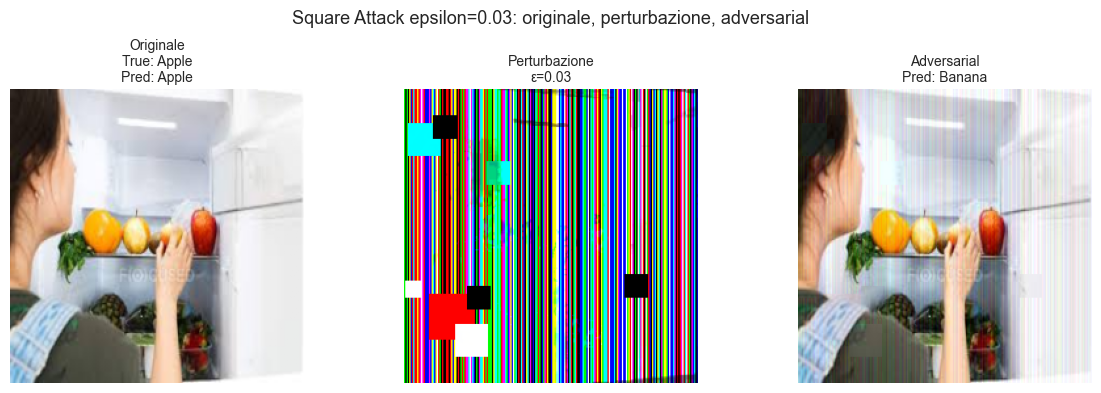

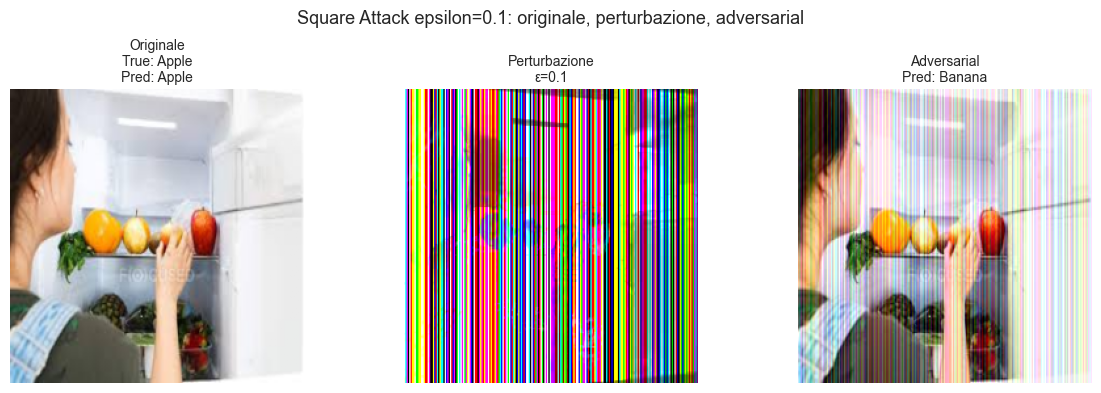

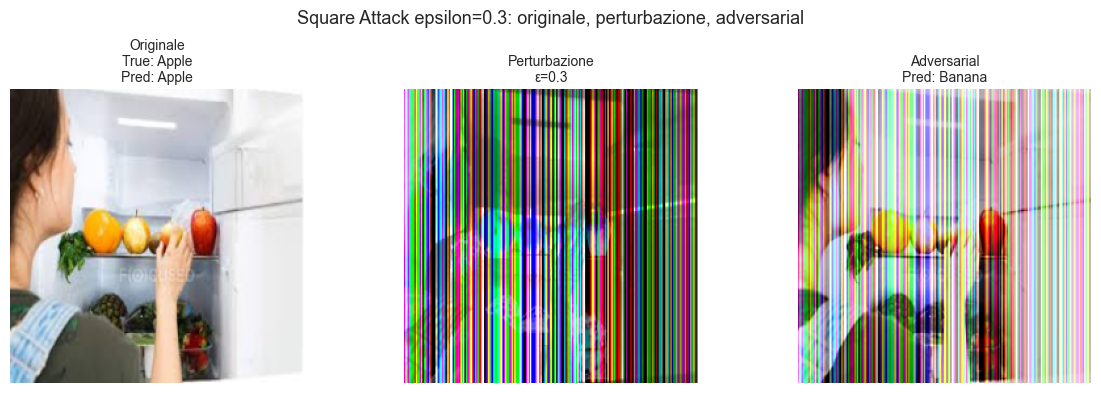

In [9]:
epsilon_to_plot = [0.03, 0.1, 0.3]

for epsilon in epsilon_to_plot:

    if epsilon not in square_examples_store:
        print(f"Nessun esempio trovato per epsilon={epsilon}, saltato")
        continue

    example = square_examples_store[epsilon]

    img_original = example["img_original"].permute(1, 2, 0).numpy()
    img_original = np.clip(img_original, 0, 1)

    img_adv = example["img_adv"].permute(1, 2, 0).numpy()
    img_adv = np.clip(img_adv, 0, 1)

    perturbation = example["perturbation"].permute(1, 2, 0).numpy()

    # per visualizzare la perturbazione come immagine RGB:
    # -epsilon diventa 0 (nero), 0 diventa 0.5 (grigio), +epsilon diventa 1 (bianco)
    perturbation_plot = perturbation / epsilon
    perturbation_plot = (perturbation_plot + 1) / 2
    perturbation_plot = np.clip(perturbation_plot, 0, 1)

    true_label = class_names[example["true_label"]]
    clean_pred = class_names[example["clean_pred"]]
    adv_pred = class_names[example["adv_pred"]]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img_original)
    axes[0].set_title(
        f"Originale\nTrue: {true_label}\nPred: {clean_pred}",
        fontsize=10
    )
    axes[0].axis('off')

    axes[1].imshow(perturbation_plot)
    axes[1].set_title(
        f"Perturbazione\nε={epsilon}",
        fontsize=10
    )
    axes[1].axis('off')

    axes[2].imshow(img_adv)
    axes[2].set_title(
        f"Adversarial\nPred: {adv_pred}",
        fontsize=10
    )
    axes[2].axis('off')

    plt.suptitle(
        f"Square Attack epsilon={epsilon}: originale, perturbazione, adversarial",
        fontsize=13
    )

    plt.tight_layout()

    plt.savefig(
        results_path / f"Square_examples_epsilon_{epsilon}.png",
        dpi=120,
        bbox_inches='tight'
    )

    plt.show()


/tmp/ipykernel_4101056/3905064418.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eps_labels, y=acc_drop, palette='Reds', ax=ax)
/tmp/ipykernel_4101056/3905064418.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eps_labels, y=asr, palette='Blues', ax=ax)
/tmp/ipykernel_4101056/3905064418.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eps_labels, y=times, palette='Greens', ax=ax)


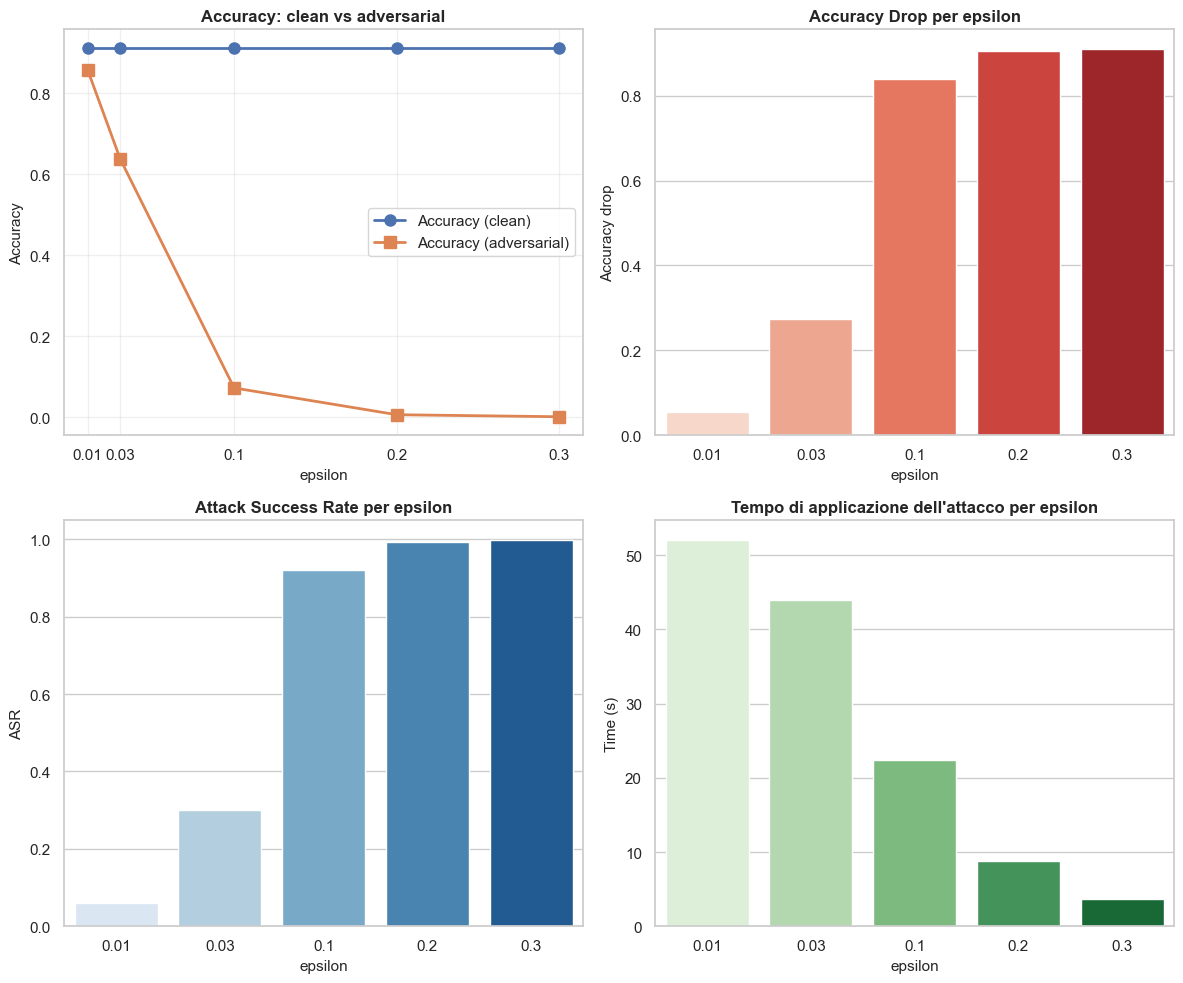

       attack  epsilon  max_queries  accuracy  accuracy_adv      asr    mean_l2  mean_linf  mean_queries    time_s  accuracy_drop
Square Attack     0.01          500  0.911824      0.856713 0.060440   3.765701       0.01    479.212088 52.083012       0.055110
Square Attack     0.03          500  0.911824      0.637275 0.301099  11.184234       0.03    389.934066 43.897624       0.274549
Square Attack     0.10          500  0.911824      0.072144 0.920879  36.275448       0.10    115.832967 22.361048       0.839679
Square Attack     0.20          500  0.911824      0.006012 0.993407  69.886711       0.20     29.749451  8.837516       0.905812
Square Attack     0.30          500  0.911824      0.001002 0.998901 100.926460       0.30     12.280220  3.697696       0.910822


In [6]:
square_results_df = pd.DataFrame(square_results)

eps = square_results_df["epsilon"].tolist()
acc = square_results_df["clean_accuracy"].tolist()
acc_adv = square_results_df["adv_accuracy"].tolist()
acc_drop = (square_results_df["clean_accuracy"] - square_results_df["adv_accuracy"]).tolist()
asr = square_results_df["asr"].tolist()
times = square_results_df["time_seconds"].tolist()

eps_labels = [str(e) for e in eps]

sns.set(style='whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# accuracy clean vs adversarial
ax = axes[0, 0]
ax.plot(eps, acc, marker='o', label='Accuracy (clean)', linewidth=2, markersize=8)
ax.plot(eps, acc_adv, marker='s', label='Accuracy (adversarial)', linewidth=2, markersize=8)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_xticks(eps)
ax.set_xticklabels(eps_labels)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Accuracy: clean vs adversarial', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# accuracy drop
ax = axes[0, 1]
sns.barplot(x=eps_labels, y=acc_drop, palette='Reds', ax=ax)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_ylabel('Accuracy drop', fontsize=11)
ax.set_title('Accuracy Drop per epsilon', fontsize=12, fontweight='bold')

# Attack Success Rate
ax = axes[1, 0]
sns.barplot(x=eps_labels, y=asr, palette='Blues', ax=ax)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_ylabel('ASR', fontsize=11)
ax.set_title('Attack Success Rate per epsilon', fontsize=12, fontweight='bold')

# tempo
ax = axes[1, 1]
sns.barplot(x=eps_labels, y=times, palette='Greens', ax=ax)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_ylabel('Time (s)', fontsize=11)
ax.set_title("Tempo di applicazione dell'attacco per epsilon", fontsize=12, fontweight='bold')

plt.tight_layout()

plt.savefig(
    results_path / 'Square_metrics_summary.png',
    dpi=120,
    bbox_inches='tight'
)

plt.show()

summary_df = square_results_df.copy()
summary_df["accuracy_drop"] = summary_df["clean_accuracy"] - summary_df["adv_accuracy"]

summary_df = summary_df.rename(columns={
    "clean_accuracy": "accuracy",
    "adv_accuracy": "accuracy_adv",
    "time_seconds": "time_s"
})

summary_df.to_csv(
    results_path / 'Square_metrics_summary.csv',
    index=False
)

print(summary_df.to_string(index=False))

## 6. Adversarial Training

Addestramento di nuovi modelli con dati misti: 50% immagini originali + 50% immagini perturbate
(Square Attack con epsilon=[0.0005, 0.003, 0.01], max_queries=20)


In [7]:
epsilon_adv_training = [0.03, 0.1, 0.3]

max_queries_adv_training = 20
p_init_adv_training = 0.05

model_path = ROOT / "models" / "best_resnet18.pt"

adv_loss_fn = nn.CrossEntropyLoss()

num_epochs = 30
patience = 10

adv_train_histories = {}
best_val_losses = {}
model_save_paths = {}

for epsilon in epsilon_adv_training:

    print(f"\nAdversarial training Square Attack con epsilon = {epsilon}, max_queries = {max_queries_adv_training}")

    square_model = models.resnet18(pretrained=True)
    square_model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)
    square_model = square_model.to(device)
    square_model.load_state_dict(torch.load(model_path))

    adv_optimizer = torch.optim.Adam(square_model.parameters(), lr=0.0001)

    best_val_loss = float('inf')
    patience_counter = 0

    adv_train_history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    model_save_path = ROOT / "models" / f"best_square_{epsilon}.pt"

    for epoch in range(num_epochs):

        square_model.train()

        epoch_loss = 0
        correct_train = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f"epsilon={epsilon} - Epoch {epoch+1}/{num_epochs}"):

            images = images.to(device)
            labels = labels.to(device)

            batch_size_half = images.size(0) // 2

            clean_images = images[:batch_size_half]

            square_model.eval()

            adv_images, perturbation, queries = square_attack(
                square_model,
                images[batch_size_half:].clone().detach(),
                labels[batch_size_half:],
                epsilon,
                max_queries_adv_training,
                p_init_adv_training
            )

            square_model.train()

            mixed_images = torch.cat([clean_images, adv_images], dim=0)
            mixed_labels = labels

            adv_optimizer.zero_grad()

            outputs = square_model(NORMALIZE(mixed_images))
            loss = adv_loss_fn(outputs, mixed_labels)

            loss.backward()
            adv_optimizer.step()

            epoch_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct_train += (preds == mixed_labels).sum().item()
            total_train += mixed_labels.size(0)

        train_loss = epoch_loss / len(train_loader)
        train_acc = correct_train / total_train

        # validazione su immagini pulite
        square_model.eval()

        val_loss = 0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = square_model(NORMALIZE(images))
                loss = adv_loss_fn(outputs, labels)

                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc = correct_val / total_val

        adv_train_history['train_loss'].append(train_loss)
        adv_train_history['train_acc'].append(train_acc)
        adv_train_history['val_loss'].append(val_loss)
        adv_train_history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

        if val_loss < best_val_loss:

            best_val_loss = val_loss
            patience_counter = 0

            torch.save(square_model.state_dict(), model_save_path)

            print("Nuovo migliore modello salvato")

        else:

            patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    adv_train_histories[epsilon] = adv_train_history
    best_val_losses[epsilon] = best_val_loss
    model_save_paths[epsilon] = model_save_path

    print(f"Training completato per epsilon={epsilon}")
    print(f"Miglior validation loss: {best_val_loss:.4f}")
    print(f"Modello salvato in: {model_save_path}")

/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Adversarial training Square Attack con epsilon = 0.03, max_queries = 20


epsilon=0.03 - Epoch 1/30:   8%|▊         | 19/250 [00:01<00:13, 17.72it/s]

epsilon=0.03 - Epoch 1/30: 100%|██████████| 250/250 [00:14<00:00, 17.65it/s]


Epoch 1: Train Loss=0.1580, Train Acc=0.9446, Val Loss=0.2866, Val Acc=0.9048
Nuovo migliore modello salvato


...

Epoch 11: Train Loss=0.0456, Train Acc=0.9853, Val Loss=0.3664, Val Acc=0.8928


epsilon=0.3 - Epoch 12/30: 100%|██████████| 250/250 [00:14<00:00, 17.42it/s]


Epoch 12: Train Loss=0.0358, Train Acc=0.9877, Val Loss=0.3678, Val Acc=0.8958


epsilon=0.3 - Epoch 13/30: 100%|██████████| 250/250 [00:14<00:00, 17.36it/s]


Epoch 13: Train Loss=0.0392, Train Acc=0.9861, Val Loss=0.3537, Val Acc=0.8958
Early stopping at epoch 13
Training completato per epsilon=0.3
Miglior validation loss: 0.2407
Modello salvato in: ../models/best_square_0.3.pt


## 7. Confronto: Modello Originale vs Modello Square Attack

Confronto del modello originale con i modelli addestrati avversarialmente con Square Attack.

Metriche:
- accuracy clean
- accuracy adversarial
- accuracy drop
- ASR
- query medie per immagine (solo per il modello sotto attacco)



Confronto Square Attack con epsilon test = 0.01


Confronto Square epsilon=0.01: 100%|██████████| 32/32 [03:34<00:00,  6.69s/it]


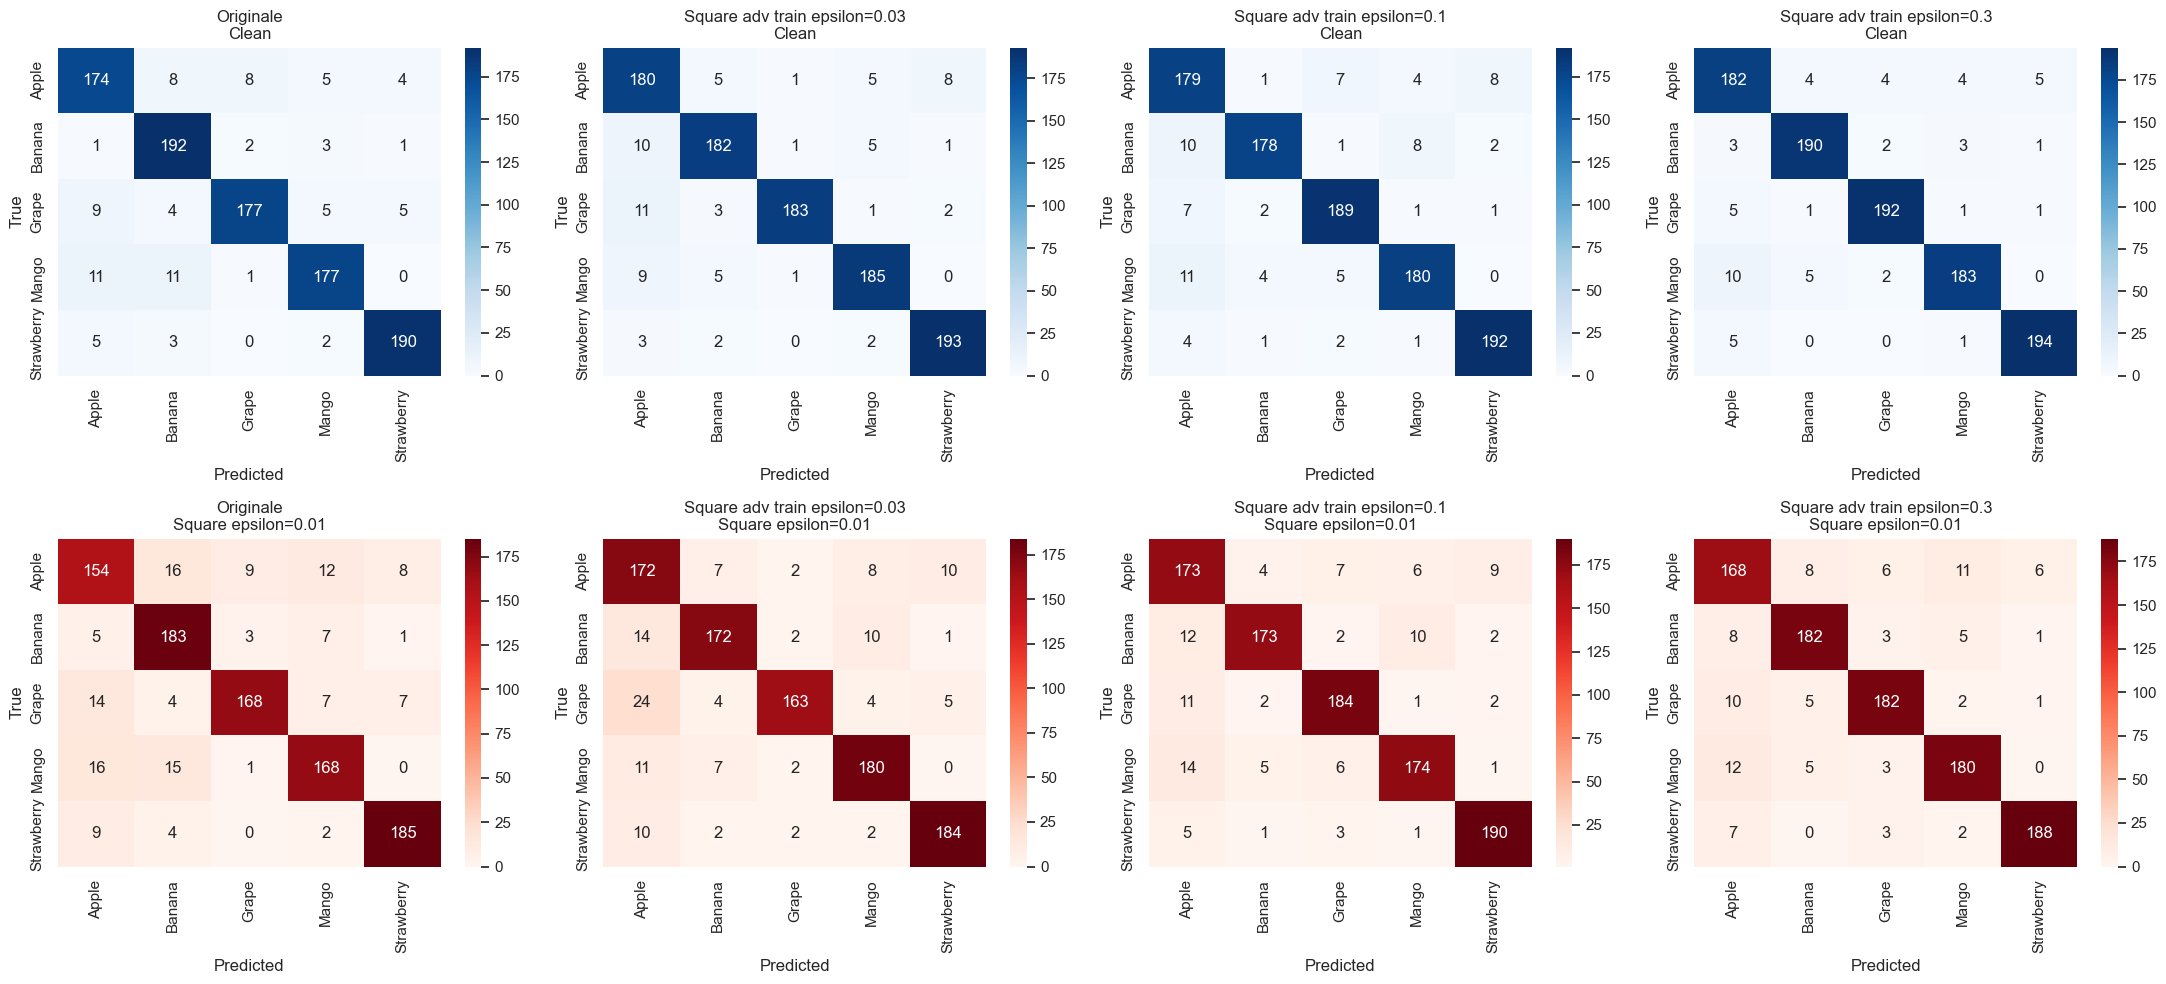


Confronto Square Attack con epsilon test = 0.03


Confronto Square epsilon=0.03: 100%|██████████| 32/32 [03:12<00:00,  6.01s/it]


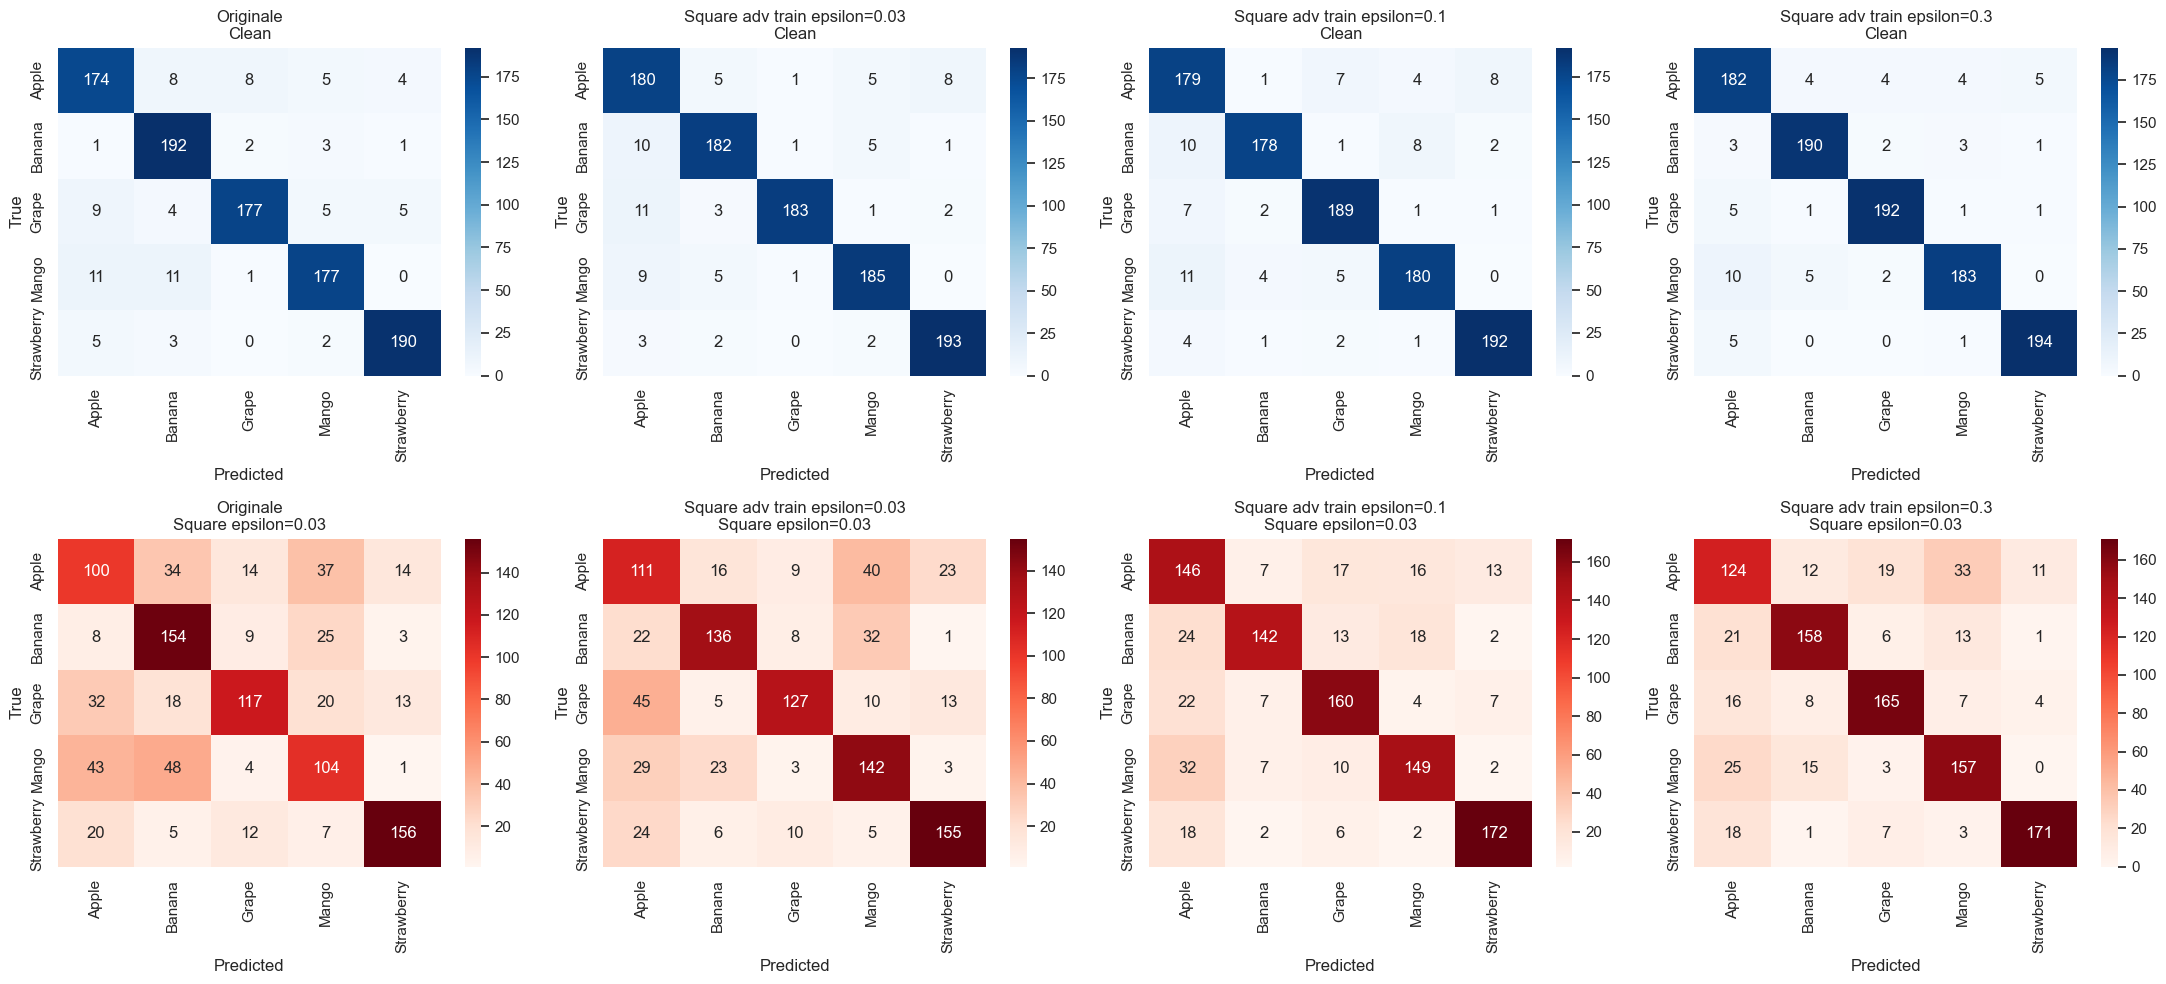


Confronto Square Attack con epsilon test = 0.1


Confronto Square epsilon=0.1: 100%|██████████| 32/32 [01:58<00:00,  3.70s/it]


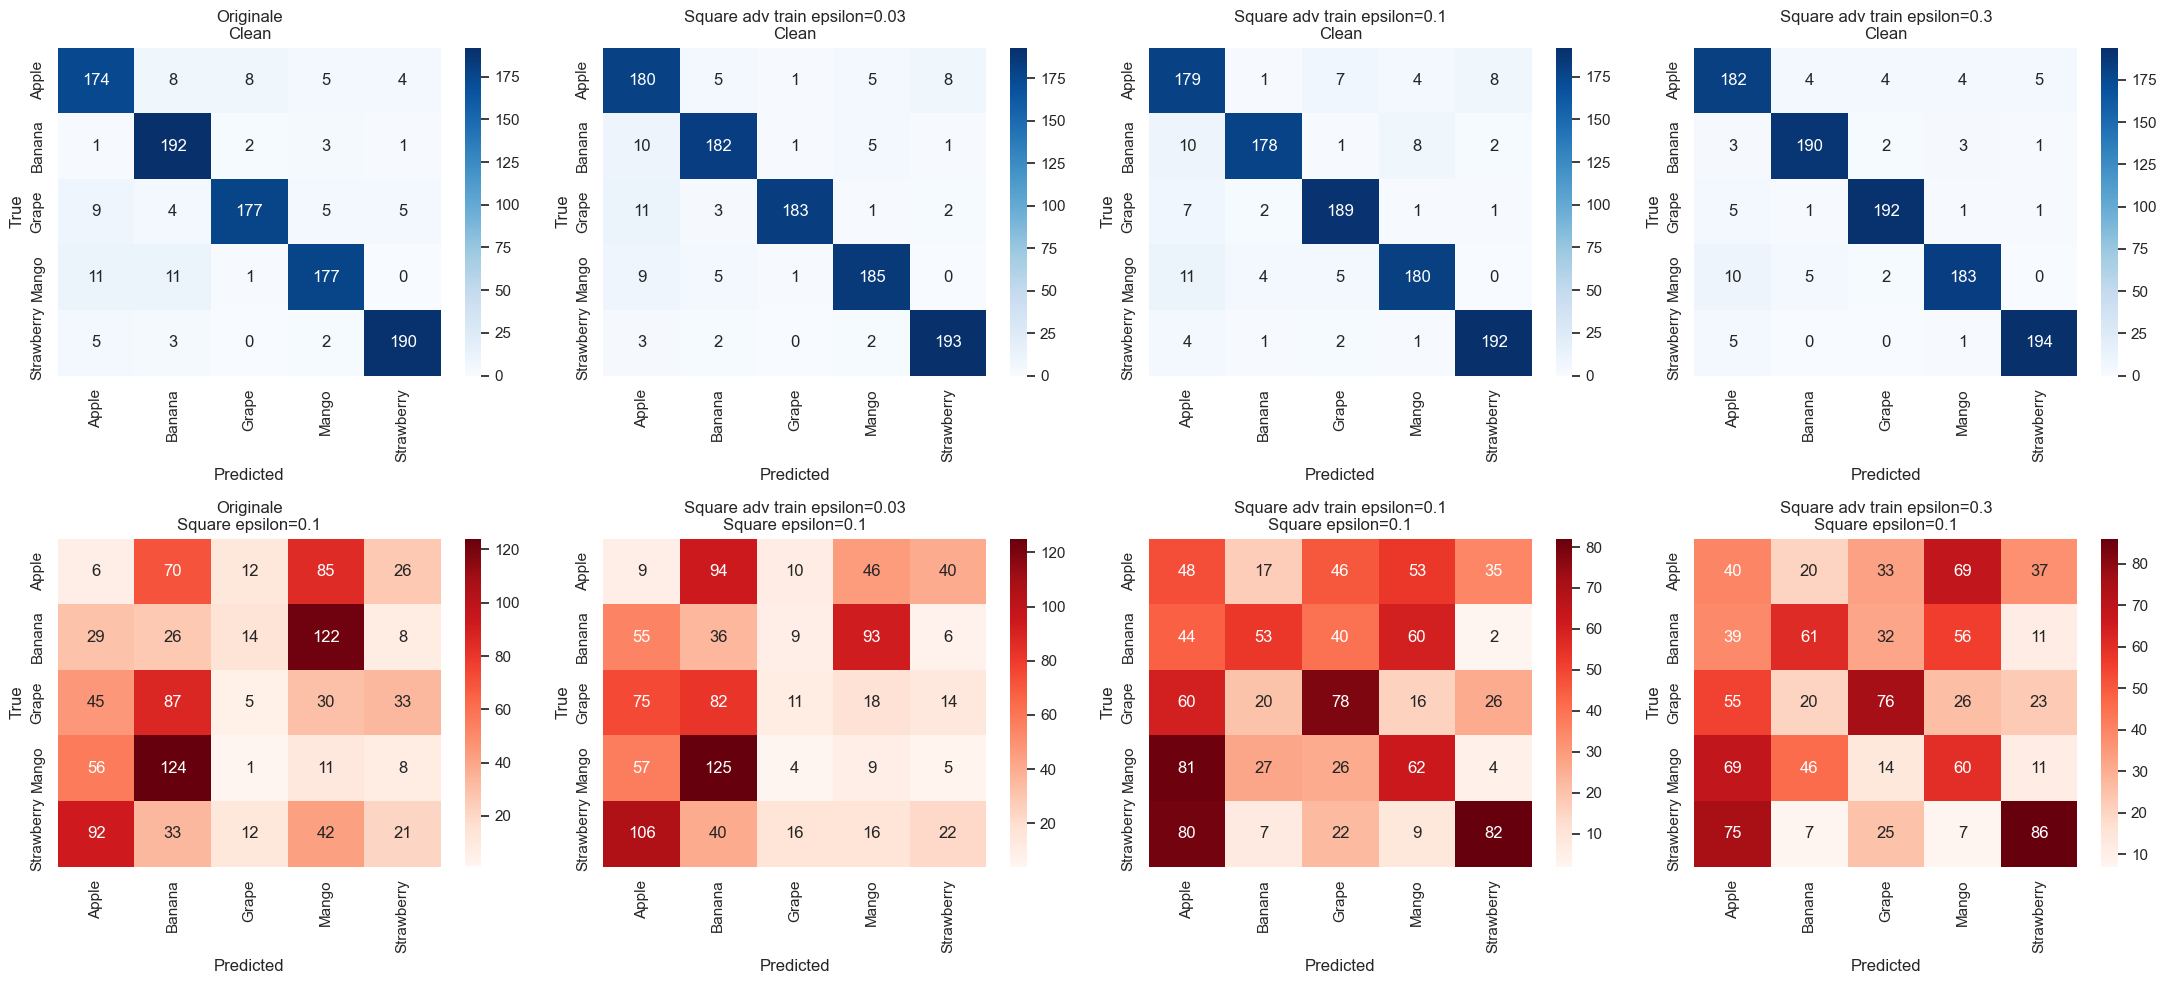


Confronto Square Attack con epsilon test = 0.2


Confronto Square epsilon=0.2: 100%|██████████| 32/32 [01:03<00:00,  2.00s/it]


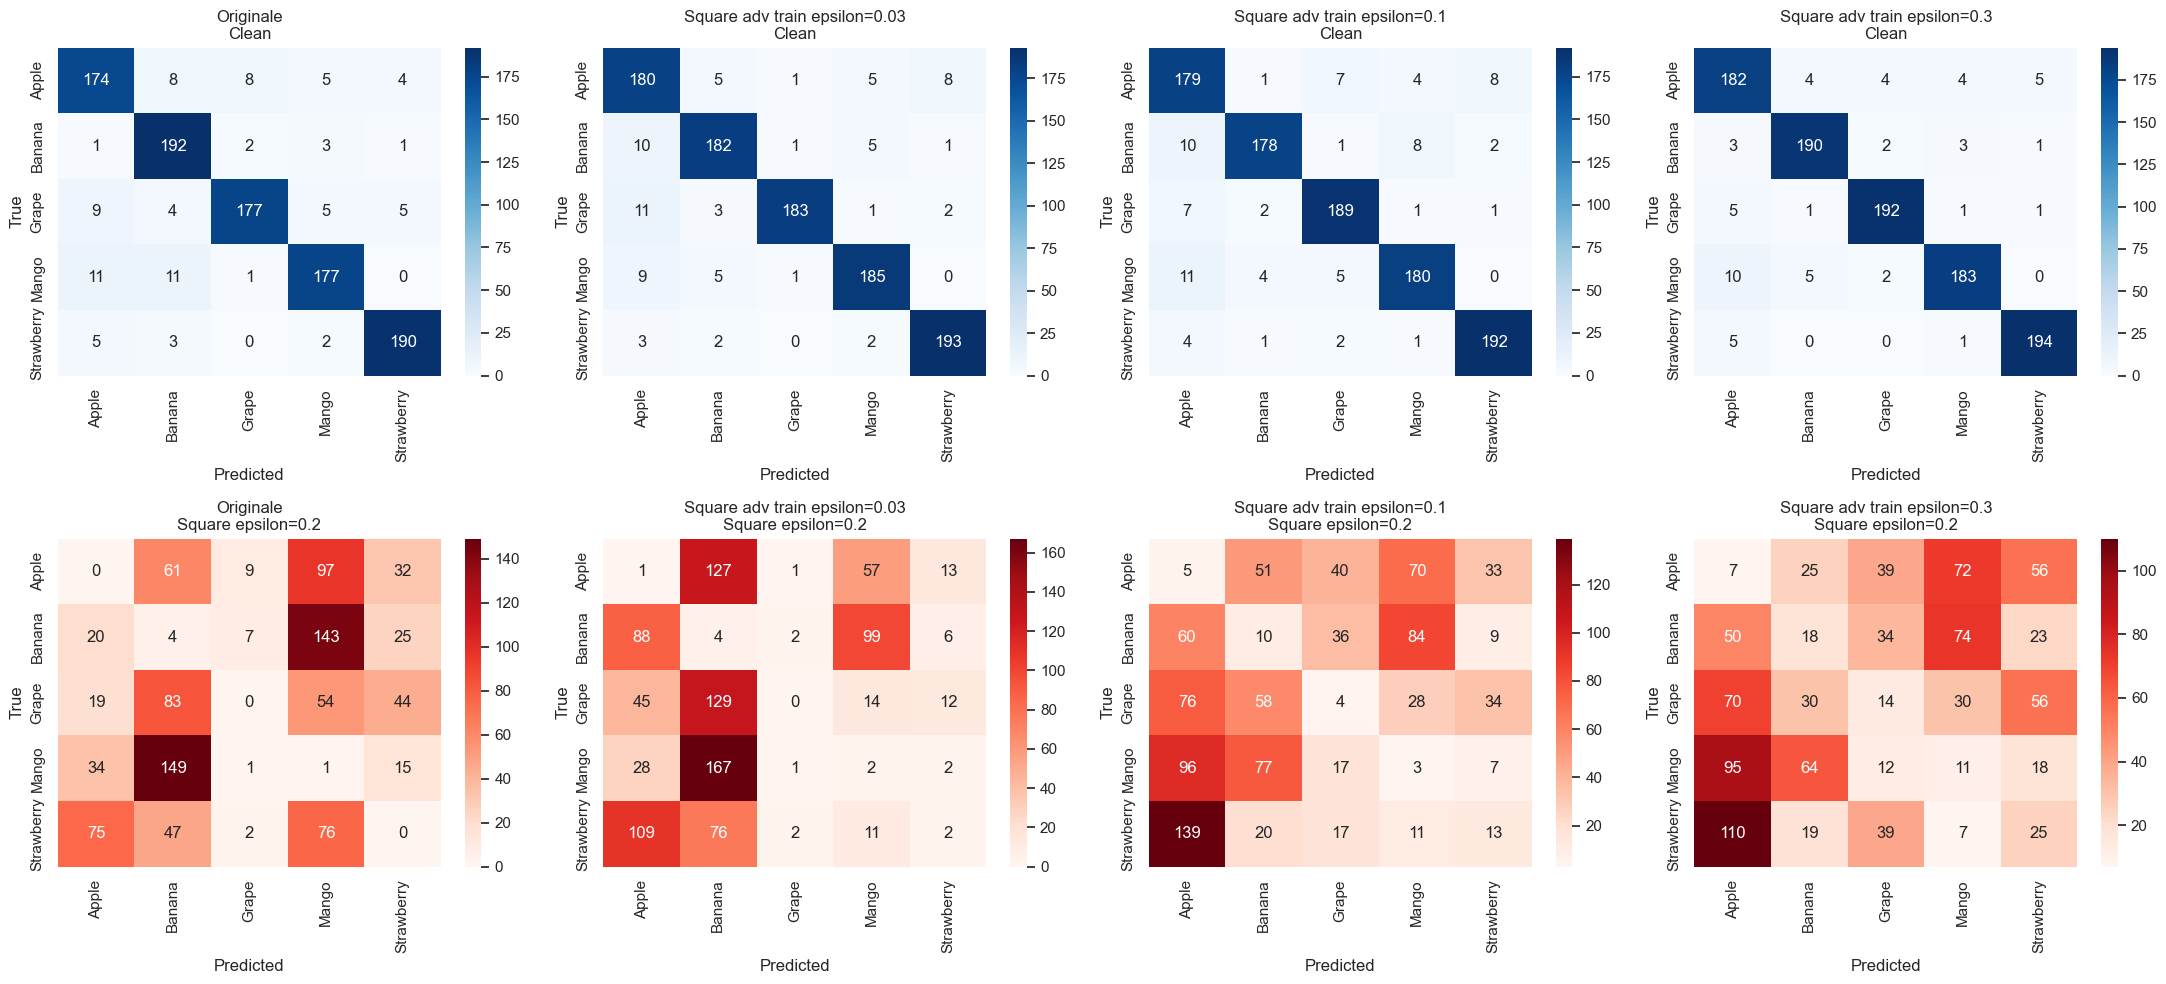


Confronto Square Attack con epsilon test = 0.3


Confronto Square epsilon=0.3: 100%|██████████| 32/32 [00:36<00:00,  1.15s/it]


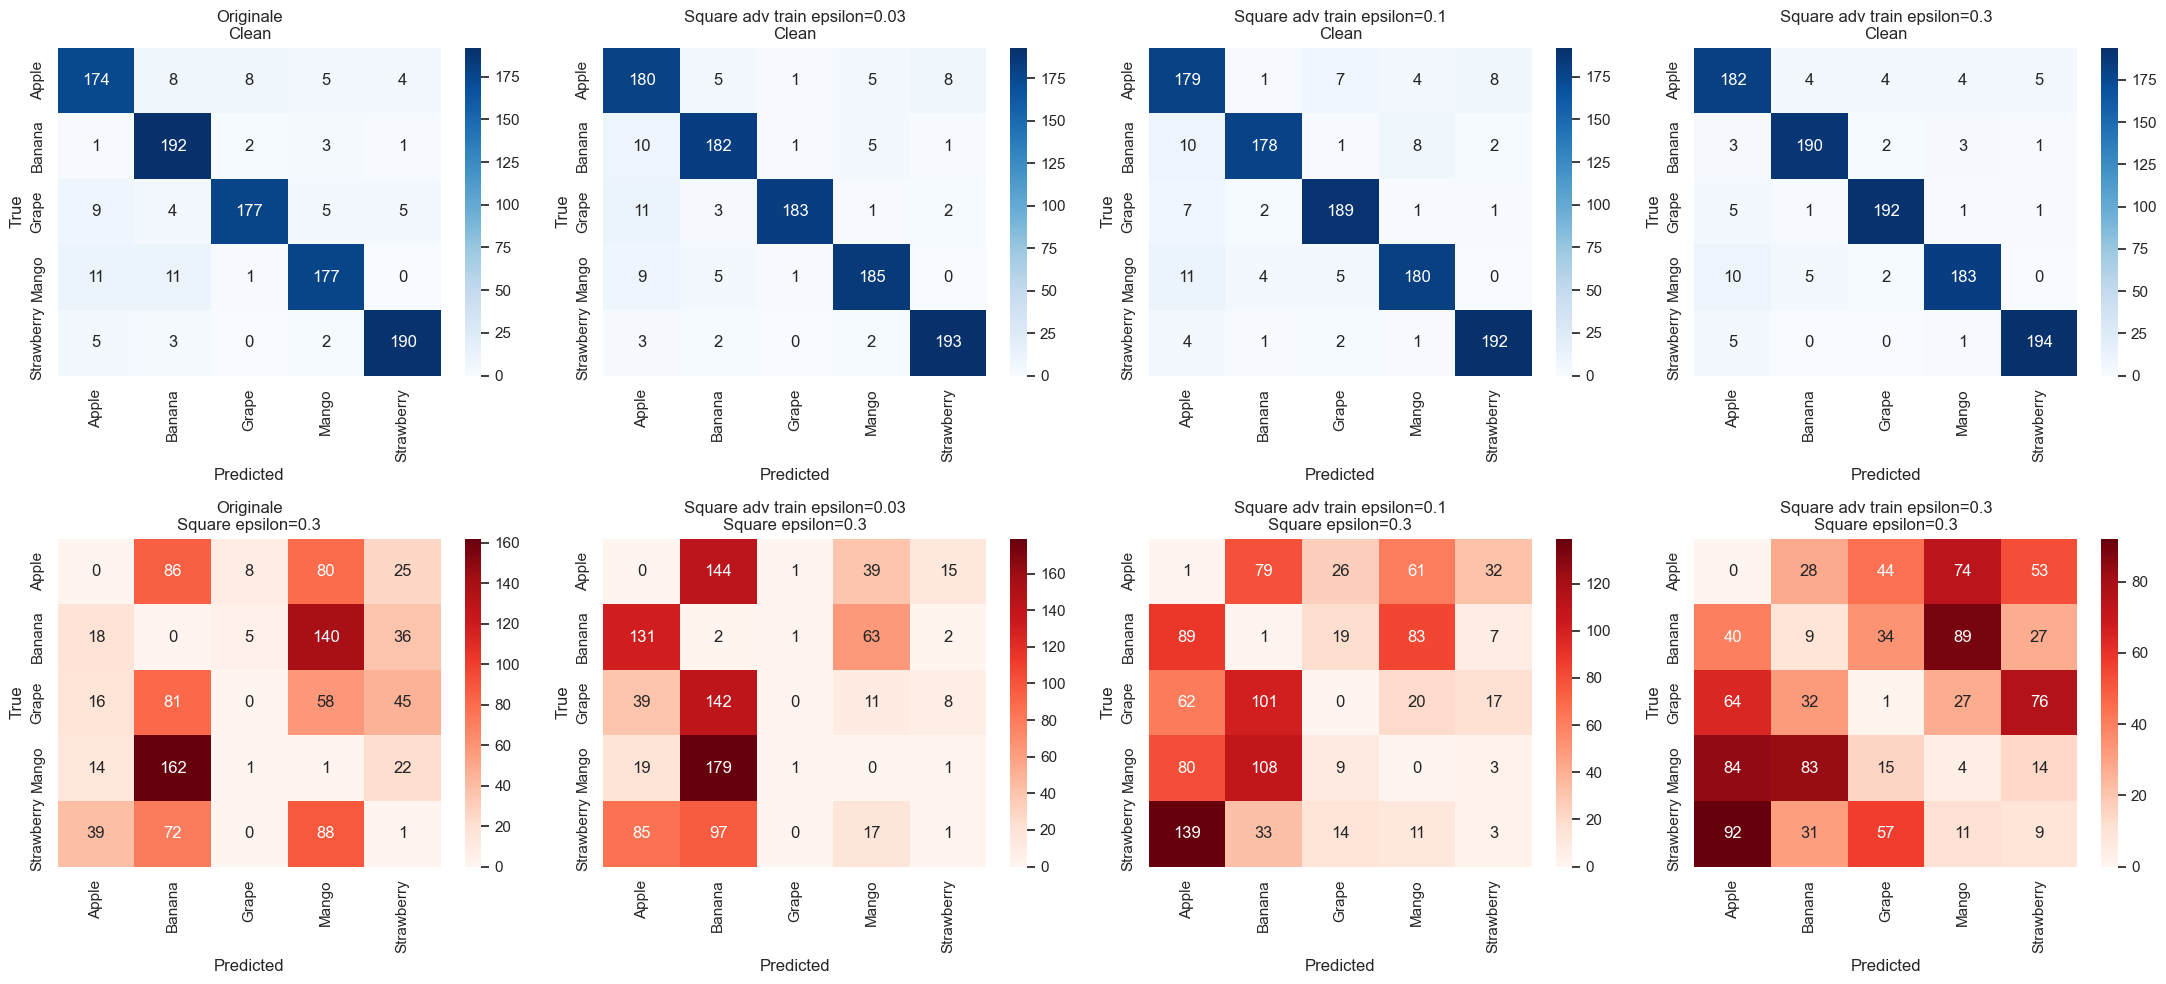

                      model  epsilon_training  epsilon_attack  accuracy_clean  accuracy_adversarial  accuracy_drop      asr    mean_l2  mean_linf  mean_queries
                  Originale               NaN            0.01        0.911824              0.859719       0.052104 0.057143   3.765704       0.01    478.952747
Adversarial Training Square              0.03            0.01        0.924850              0.872745       0.052104 0.056338   3.763878       0.01    480.294691
Adversarial Training Square              0.10            0.01        0.919840              0.895792       0.024048 0.026144   3.764904       0.01    490.384532
Adversarial Training Square              0.30            0.01        0.942886              0.901804       0.041082 0.043571   3.765198       0.01    483.984060
                  Originale               NaN            0.03        0.911824              0.632265       0.279559 0.306593  11.181721       0.03    390.557143
Adversarial Training Square             

In [8]:
epsilon_test_values = [0.01, 0.03, 0.1, 0.2, 0.3]

max_queries_test = 500
p_init_test = 0.05

comparison_models = {
    'Originale': {
        'model': model,
        'epsilon_training': None
    }
}

for epsilon_training in epsilon_adv_training:

    square_model = models.resnet18(pretrained=True)
    square_model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)
    square_model = square_model.to(device)

    model_save_path = ROOT / "models" / f"best_square_{epsilon_training}.pt"
    square_model.load_state_dict(torch.load(model_save_path))
    square_model.eval()

    comparison_models[f'Square adv train epsilon={epsilon_training}'] = {
        'model': square_model,
        'epsilon_training': epsilon_training
    }

model.eval()

comparison_results = []

for epsilon_test in epsilon_test_values:

    print(f"\nConfronto Square Attack con epsilon test = {epsilon_test}")

    comparison_stats = {}

    for model_name in comparison_models:
        comparison_stats[model_name] = {
            'correct_clean': 0,
            'correct_adv': 0,
            'attack_success': 0,
            'total_l2': 0,
            'total_linf': 0,
            'total_queries': 0,
            'preds_clean': [],
            'preds_adv': []
        }

    total = 0
    all_labels = []

    for images, labels in tqdm(test_loader, desc=f"Confronto Square epsilon={epsilon_test}"):

        images = images.to(device)
        labels = labels.to(device)

        all_labels.extend(labels.cpu().numpy())
        total += labels.size(0)

        for model_name, model_info in comparison_models.items():

            current_model = model_info['model']

            # immagini pulite
            with torch.no_grad():
                outputs_clean = current_model(NORMALIZE(images))
                preds_clean = torch.argmax(outputs_clean, dim=1)

            # immagini adversarial generate contro il modello corrente
            adv_images, perturbation, queries = square_attack(
                current_model,
                images.clone().detach(),
                labels,
                epsilon_test,
                max_queries_test,
                p_init_test
            )

            with torch.no_grad():
                outputs_adv = current_model(NORMALIZE(adv_images))
                preds_adv = torch.argmax(outputs_adv, dim=1)

            clean_correct = (preds_clean == labels)
            success = clean_correct & (preds_adv != labels)

            comparison_stats[model_name]['correct_clean'] += clean_correct.sum().item()

            comparison_stats[model_name]['correct_adv'] += (preds_adv == labels).sum().item()

            comparison_stats[model_name]['attack_success'] += success.sum().item()

            perturbation_flat = perturbation.view(perturbation.size(0), -1)

            l2_norms = torch.norm(perturbation_flat, p=2, dim=1)
            linf_norms = torch.norm(perturbation_flat, p=float('inf'), dim=1)

            comparison_stats[model_name]['total_l2'] += l2_norms[clean_correct].sum().item()

            comparison_stats[model_name]['total_linf'] += linf_norms[clean_correct].sum().item()

            comparison_stats[model_name]['total_queries'] += queries[clean_correct].sum().item()

            comparison_stats[model_name]['preds_clean'].extend(preds_clean.cpu().numpy())

            comparison_stats[model_name]['preds_adv'].extend(preds_adv.cpu().numpy())

    # metriche
    for model_name, model_info in comparison_models.items():

        stats = comparison_stats[model_name]

        accuracy_clean = stats['correct_clean'] / total
        accuracy_adv = stats['correct_adv'] / total
        accuracy_drop = accuracy_clean - accuracy_adv
        asr = stats['attack_success'] / stats['correct_clean']

        mean_l2 = stats['total_l2'] / stats['correct_clean']
        mean_linf = stats['total_linf'] / stats['correct_clean']
        mean_queries = stats['total_queries'] / stats['correct_clean']

        if model_info['epsilon_training'] is None:
            csv_model_name = 'Originale'
        else:
            csv_model_name = 'Adversarial Training Square'

        comparison_results.append({
            'model': csv_model_name,
            'epsilon_training': model_info['epsilon_training'],
            'epsilon_attack': epsilon_test,
            'accuracy_clean': accuracy_clean,
            'accuracy_adversarial': accuracy_adv,
            'accuracy_drop': accuracy_drop,
            'asr': asr,
            'mean_l2': mean_l2,
            'mean_linf': mean_linf,
            'mean_queries': mean_queries
        })

    # plot confusion matrix per ogni epsilon di test
    fig, axes = plt.subplots(
        2,
        len(comparison_models),
        figsize=(22, 10)
    )

    for column, (model_name, model_info) in enumerate(comparison_models.items()):

        stats = comparison_stats[model_name]

        cm_clean = confusion_matrix(
            all_labels,
            stats['preds_clean']
        )

        cm_adv = confusion_matrix(
            all_labels,
            stats['preds_adv']
        )

        sns.heatmap(
            cm_clean,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[0, column]
        )

        axes[0, column].set_title(f'{model_name}\nClean')
        axes[0, column].set_xlabel('Predicted')
        axes[0, column].set_ylabel('True')

        sns.heatmap(
            cm_adv,
            annot=True,
            fmt='d',
            cmap='Reds',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[1, column]
        )

        axes[1, column].set_title(
            f'{model_name}\nSquare epsilon={epsilon_test}'
        )
        axes[1, column].set_xlabel('Predicted')
        axes[1, column].set_ylabel('True')

    plt.tight_layout()

    plt.savefig(
        results_path / f"Square_comparison_epsilon_{epsilon_test}.png",
        dpi=120,
        bbox_inches='tight'
    )

    plt.show()

comparison_df = pd.DataFrame(comparison_results)

print(comparison_df.to_string(index=False))

comparison_df.to_csv(
    results_path / "Square_original_vs_adv.csv",
    index=False
)